# Mask Detection - Data Analysis & Experiment Orchestration

This notebook handles data analysis and orchestrates model training experiments.

## Dataset Setup

We use the following Kaggle datasets for mask detection:

1. **Face Mask 12K Images Dataset** - https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset

In [19]:
#!/bin/bash
!kaggle datasets download ashishjangra27/face-mask-12k-images-dataset

/Users/tanliangwei/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Dataset URL: https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset
License(s): CC0-1.0
 70%|███████████████████████████▉            | 231M/330M [00:00<00:00, 1.25GB/s]
100%|████████████████████████████████████████| 330M/330M [00:00<00:00, 1.26GB/s]


In [ ]:
!unzip face-mask-12k-images-dataset.zip -d face-mask-12k-images-dataset/

## Import required packages

In [1]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

I0000 00:00:1776087712.561603    3253 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776087712.594208    3253 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776087713.522402    3253 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Load and observe data

In [2]:
#Load train and test set
test_data_root_dir = 'face-mask-12k-images-dataset/Face Mask Dataset/'
train_dir = test_data_root_dir + 'Train'
test_dir  = test_data_root_dir + 'Test'
val_dir   = test_data_root_dir + 'Validation'

In [3]:
batch_size = 32
img_height = 128
img_width = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 10000 files belonging to 2 classes.


W0000 00:00:1776087766.623096    3253 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776087766.640691    3253 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776087766.747987    3253 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 94891 MB memory:  -> device: 0, name: NVIDIA RTX PRO 6000 Blackwell Server Edition, pci bus id: 0000:76:00.0, compute capability: 12.0a


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  val_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.


In [5]:
class_names = train_ds.class_names
print(class_names)

['WithMask', 'WithoutMask']


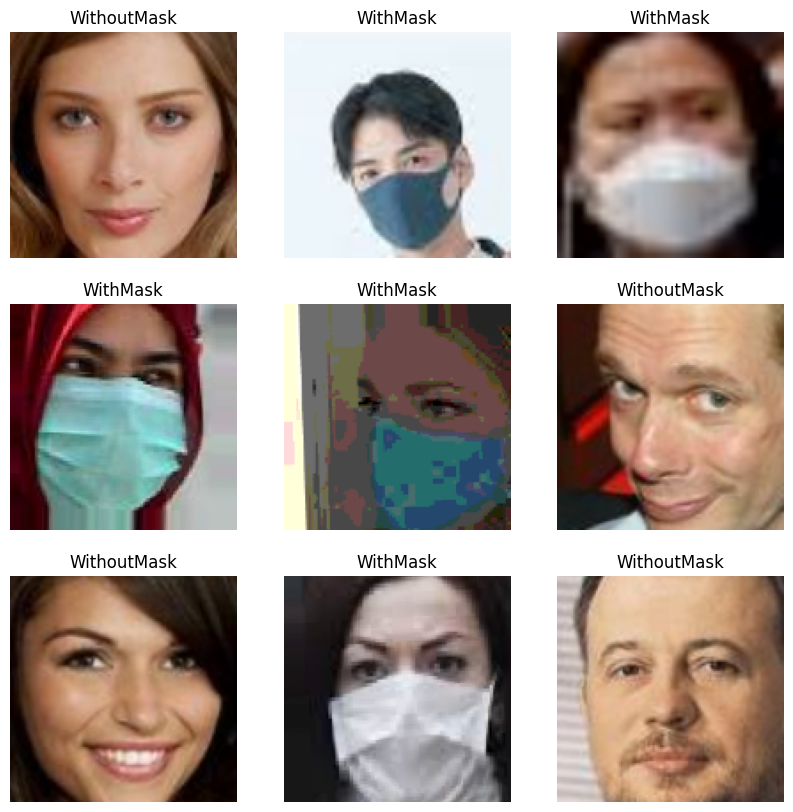

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [7]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 128, 128, 3)
(32,)


## Build Models

### Baseline model
```
model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes)
])
```

In [13]:
!python -m train baseline_cnn 

I0000 00:00:1776088098.196685   44017 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776088098.226581   44017 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776088099.213828   44017 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Loading model: baseline_cnn
Loading datasets...
Found 10000 files belonging to 2 classes.
W0000 00:00:

Loading dataset from face-mask-12k-images-dataset/Face Mask Dataset...
Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.


Finding latest checkpoint...
Loading model from: checkpoints/baseline_cnn/model-20-0.0096.h5


I0000 00:00:1776088150.022788    4753 service.cc:153] XLA service 0x744e7402e830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776088150.022833    4753 service.cc:161]   StreamExecutor [0]: NVIDIA RTX PRO 6000 Blackwell Server Edition, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776088150.061766    4753 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.



Evaluating model...


I0000 00:00:1776088150.112453    4753 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776088150.263423   70348 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776088150.407517   70355 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 76 bytes spill stores, 72 bytes spill loads



31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9909 - loss: 0.0348    


I0000 00:00:1776088151.510388    4753 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Test Loss: 0.0348
Test Accuracy: 0.9909
['WithMask', 'WithoutMask']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


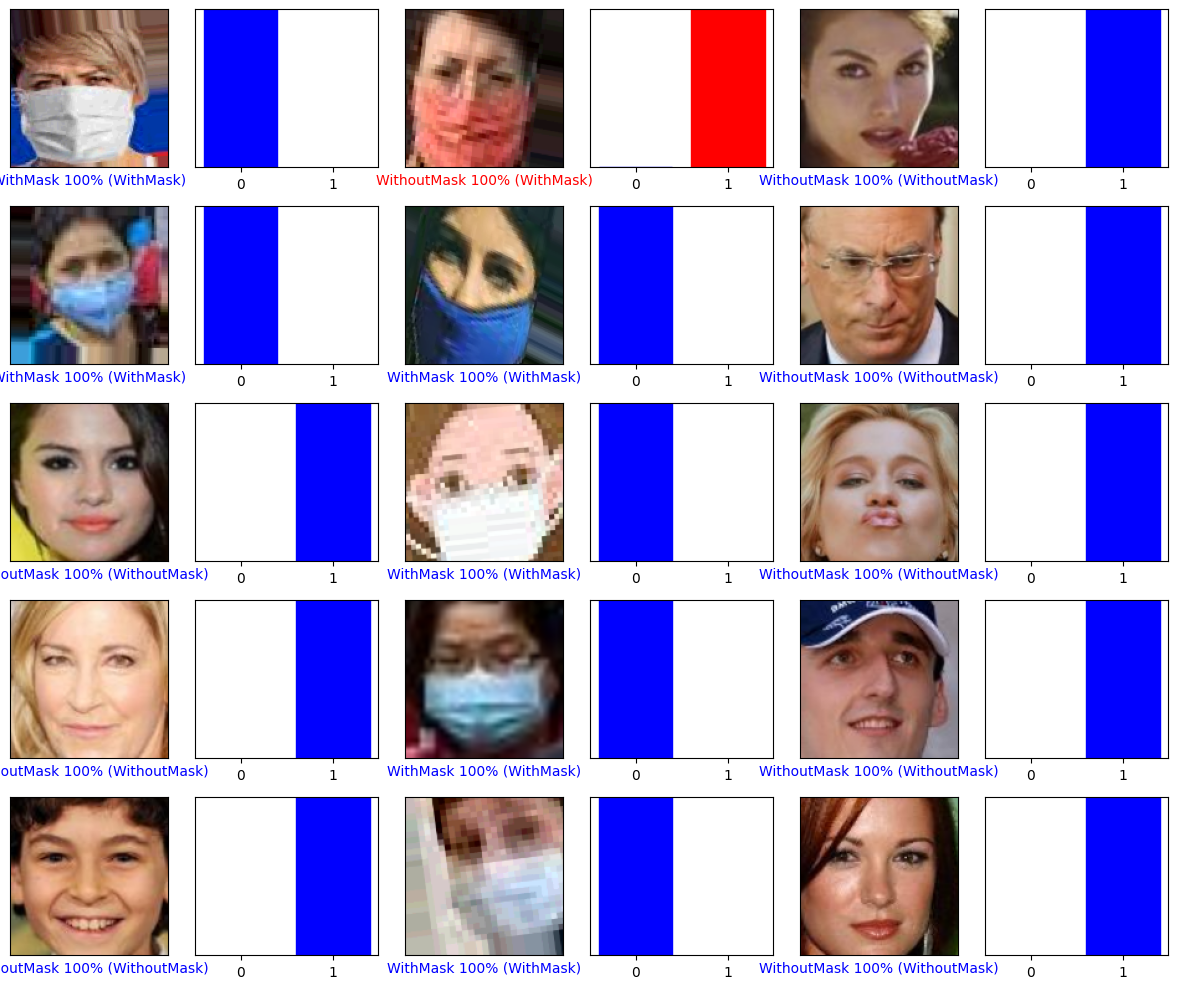

In [14]:
from train.evaluate import main

model, loss, accuracy = main("face-mask-12k-images-dataset/Face Mask Dataset")